In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
from sklearn.datasets import make_blobs

In [6]:
x,y=make_blobs(n_samples=1000,centers=3,n_features=2)

In [7]:
x

array([[ 7.74736401, -7.44224577],
       [ 7.08261543, -8.02146259],
       [ 8.45133511, -6.05520331],
       ...,
       [ 1.58959977,  3.69323732],
       [ 7.83653928, -7.91775416],
       [-4.27837232, -9.59352802]])

In [9]:
x.shape

(1000, 2)

In [10]:
y

array([2, 2, 2, 0, 2, 1, 2, 0, 0, 2, 0, 1, 0, 2, 0, 2, 2, 1, 2, 2, 0, 1,
       2, 0, 0, 1, 0, 2, 2, 1, 0, 2, 2, 1, 1, 0, 2, 0, 0, 1, 2, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 2, 0, 1, 2, 0, 2, 1, 1, 0, 0, 1, 2, 0, 0, 1,
       0, 0, 1, 2, 1, 0, 1, 1, 2, 1, 0, 2, 1, 0, 1, 1, 2, 0, 1, 1, 0, 1,
       1, 2, 0, 0, 2, 2, 0, 1, 1, 0, 0, 2, 1, 0, 1, 1, 0, 2, 1, 1, 1, 2,
       2, 1, 1, 2, 2, 2, 1, 0, 2, 2, 0, 1, 0, 2, 0, 1, 1, 0, 1, 1, 1, 1,
       1, 2, 1, 1, 2, 0, 1, 0, 0, 2, 0, 0, 2, 2, 0, 2, 2, 1, 0, 0, 0, 1,
       0, 2, 0, 1, 1, 2, 1, 1, 0, 2, 2, 1, 1, 0, 2, 0, 0, 1, 1, 2, 2, 1,
       0, 2, 1, 1, 0, 1, 0, 1, 0, 0, 2, 2, 2, 0, 2, 0, 0, 2, 0, 2, 2, 0,
       2, 1, 0, 2, 1, 2, 2, 2, 2, 0, 2, 1, 0, 0, 2, 1, 0, 2, 2, 2, 1, 0,
       2, 0, 0, 0, 1, 0, 2, 1, 0, 1, 0, 2, 0, 1, 1, 1, 2, 0, 1, 0, 1, 2,
       0, 1, 0, 2, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 2, 2, 0, 1,
       0, 1, 1, 2, 0, 1, 2, 0, 2, 2, 1, 2, 2, 1, 1, 0, 1, 2, 0, 1, 1, 1,
       1, 2, 1, 1, 0, 0, 1, 1, 2, 1, 2, 1, 0, 1, 0,

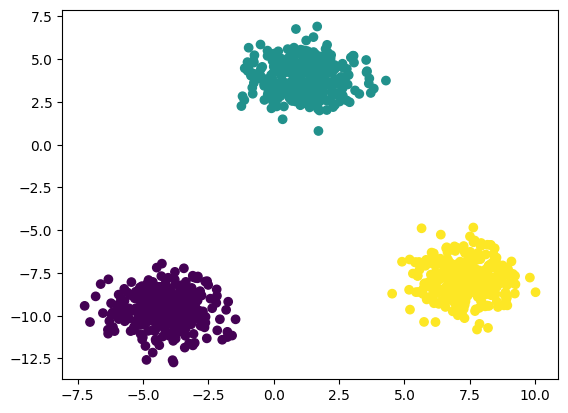

In [11]:
plt.scatter(x[:,0],x[:,1],c=y)

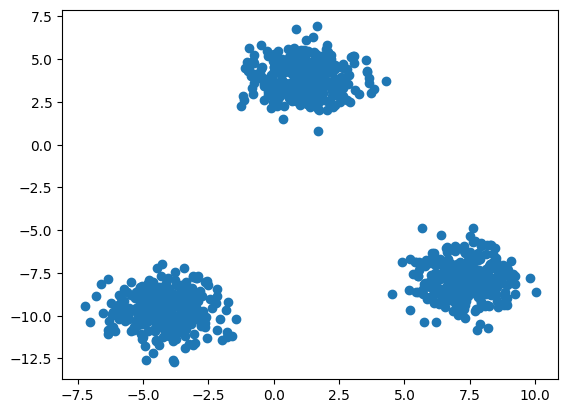

In [13]:
plt.scatter(x[:,0],x[:,1])

In [14]:
##Standardization
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [15]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.33,random_state=42)

In [16]:
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.fit_transform(x_test)

In [17]:
from sklearn.cluster import KMeans
wcss=[]
for k in range(1,11):
  kmeans=KMeans(n_clusters=k,init="k-means++")
  kmeans.fit(x_train_scaled)
  wcss.append(kmeans.inertia_)

kmeans.inertia_

The WCSS (Within-Cluster Sum of Squares) for the current model – the sum of squared distances between each point and its assigned cluster centre

In [18]:
wcss

[1340.0000000000014,
 738.833936605985,
 46.956776996448994,
 39.541115431078715,
 33.45742759058393,
 27.665311460665205,
 25.92841948711067,
 22.67158713856105,
 20.259293899494953,
 20.863694894745347]

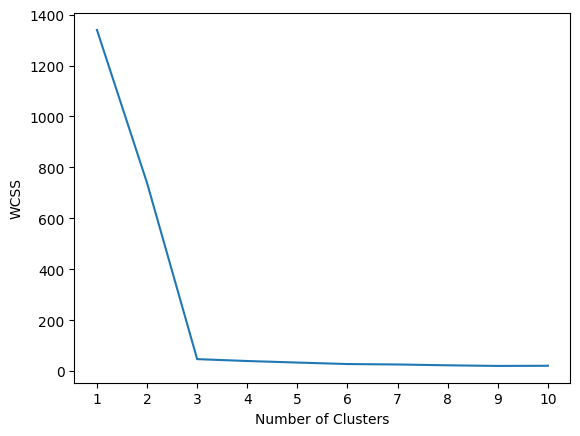

In [19]:
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [20]:
kmeans=KMeans(n_clusters=3,init="k-means++")
kmeans.fit_predict(x_train_scaled)

array([0, 1, 0, 1, 1, 0, 1, 0, 0, 2, 0, 1, 2, 2, 1, 0, 2, 0, 0, 0, 2, 2,
       1, 1, 0, 2, 0, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 0, 2, 0, 1,
       1, 1, 1, 2, 0, 1, 2, 1, 2, 2, 1, 1, 2, 2, 1, 1, 0, 0, 2, 2, 0, 1,
       2, 1, 2, 2, 0, 2, 1, 0, 0, 1, 2, 1, 1, 1, 2, 2, 2, 0, 2, 1, 1, 2,
       2, 0, 1, 2, 0, 0, 0, 1, 0, 2, 0, 1, 2, 0, 0, 0, 2, 0, 0, 0, 1, 0,
       0, 2, 2, 2, 0, 0, 0, 0, 1, 0, 2, 1, 0, 1, 2, 2, 1, 2, 1, 1, 1, 1,
       1, 2, 2, 0, 1, 0, 0, 1, 1, 1, 0, 1, 2, 2, 2, 0, 1, 0, 1, 0, 2, 0,
       1, 0, 2, 1, 0, 1, 2, 2, 2, 2, 1, 2, 1, 1, 0, 0, 2, 1, 0, 1, 0, 0,
       0, 2, 0, 0, 2, 0, 1, 1, 1, 2, 0, 2, 2, 1, 2, 1, 0, 1, 2, 0, 2, 1,
       0, 1, 0, 2, 2, 2, 1, 0, 2, 2, 2, 2, 1, 0, 1, 2, 0, 1, 2, 1, 0, 2,
       2, 2, 1, 2, 1, 2, 0, 0, 2, 1, 1, 0, 2, 0, 2, 1, 2, 1, 2, 1, 2, 0,
       0, 0, 2, 0, 0, 2, 1, 0, 2, 1, 2, 0, 0, 1, 1, 0, 0, 2, 1, 1, 1, 0,
       0, 0, 1, 0, 1, 1, 2, 0, 2, 2, 1, 1, 1, 1, 0, 2, 0, 2, 2, 2, 0, 1,
       0, 1, 1, 2, 2, 2, 1, 2, 1, 1, 0, 2, 1, 1, 1,

In [21]:
y_pred=kmeans.predict(x_test_scaled)
y_pred

array([0, 0, 0, 2, 1, 1, 1, 1, 0, 1, 2, 0, 2, 0, 2, 2, 2, 2, 0, 2, 1, 1,
       0, 2, 0, 2, 0, 1, 2, 2, 0, 0, 1, 1, 2, 1, 1, 0, 1, 0, 1, 2, 0, 2,
       2, 2, 0, 2, 2, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 2, 2, 1, 1,
       2, 0, 2, 2, 2, 1, 0, 2, 2, 2, 1, 2, 0, 1, 2, 0, 1, 0, 0, 1, 1, 0,
       0, 0, 1, 0, 2, 2, 1, 1, 0, 2, 0, 2, 1, 1, 2, 0, 1, 2, 2, 0, 1, 1,
       2, 2, 0, 0, 0, 2, 0, 2, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 2, 0, 1, 2,
       2, 1, 2, 0, 0, 1, 2, 2, 0, 0, 2, 1, 2, 1, 0, 0, 0, 0, 2, 2, 2, 2,
       1, 0, 2, 0, 0, 1, 1, 0, 1, 0, 2, 1, 0, 0, 0, 0, 1, 1, 1, 2, 2, 1,
       2, 0, 0, 0, 1, 1, 2, 0, 1, 0, 2, 0, 0, 1, 1, 0, 2, 2, 2, 1, 1, 1,
       0, 2, 2, 0, 2, 0, 0, 2, 2, 0, 2, 1, 2, 1, 2, 0, 2, 0, 0, 2, 1, 0,
       1, 1, 2, 2, 0, 1, 0, 2, 2, 2, 2, 0, 1, 0, 2, 1, 1, 0, 0, 1, 0, 1,
       2, 1, 1, 1, 0, 1, 2, 2, 1, 1, 2, 1, 1, 2, 0, 0, 0, 2, 1, 2, 0, 2,
       2, 1, 0, 0, 2, 2, 1, 1, 2, 0, 1, 1, 1, 0, 2, 1, 1, 2, 0, 0, 0, 0,
       2, 2, 2, 1, 0, 0, 1, 2, 0, 0, 0, 0, 0, 1, 0,

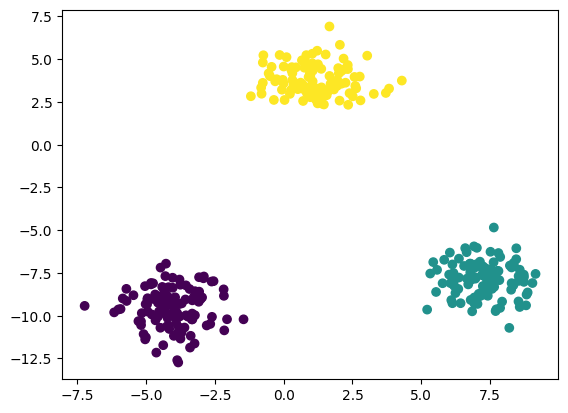

In [22]:
plt.scatter(x_test[:,0],x_test[:,1],c=y_pred)

##Validating the k value

1.Silhouette scoring

2.knee Locator

In [23]:
### KneeLocator
!pip install kneed

In [24]:
from kneed import KneeLocator
kl=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")

def __init__(x: Iterable[float],

y: Iterable[float],

 S: float=1.0,

 curve: str='concave',

  direction: str='increasing',
  
   interp_method: str='interp1d', online: bool=False, polynomial_degree: int=7)

In [25]:
kl.elbow

np.int64(3)

In [27]:
###Silhouette Score
from sklearn.metrics import silhouette_score
silhouette_coefficients=[]
for k in range(2,11):
  kmeans=KMeans(n_clusters=k,init="k-means++")
  kmeans.fit(x_train_scaled)
  score=silhouette_score(x_train_scaled,kmeans.labels_)
  silhouette_coefficients.append(score)

```python
from sklearn.metrics import silhouette_score

silhouette_coefficients = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init="k-means++")
    kmeans.fit(x_train_scaled)
    score = silhouette_score(x_train_scaled, kmeans.labels_)
    silhouette_coefficients.append(score)
```

It **evaluates** how well‑separated the clusters are for different values of `k` (from 2 to 10) using the **Silhouette Score**, and stores the scores in a list.

---

## Breakdown of Each Part

| Line | What It Does |
| :--- | :--- |
| `from sklearn.metrics import silhouette_score` | Imports the silhouette score function |
| `silhouette_coefficients = []` | Creates an empty list to store scores |
| `for k in range(2, 11)` | Loops through cluster numbers from 2 to 10 |
| `kmeans = KMeans(n_clusters=k, init="k-means++")` | Initializes a K‑Means model with `k` clusters |
| `kmeans.fit(x_train_scaled)` | Fits the model to the scaled training data |
| `score = silhouette_score(x_train_scaled, kmeans.labels_)` | Computes the silhouette score for this clustering |
| `silhouette_coefficients.append(score)` | Adds the score to the list |

---

## What is the Silhouette Score?

| Aspect | Explanation |
| :--- | :--- |
| **Range** | Between **-1** and **+1** |
| **+1** | Clusters are well‑separated and dense (best) |
| **0** | Clusters overlap or are neutral |
| **-1** | Points are assigned to the wrong cluster (worst) |

> **Higher silhouette score = better clustering.**




```python
score = silhouette_score(x_train_scaled, kmeans.labels_)
```

**In simple words:**  
It calculates a **score** that tells you **how good your clustering is** — i.e., how well-separated and compact your clusters are.

---

## Breaking It Down

| Part | What It Means |
| :--- | :--- |
| `silhouette_score(...)` | A function that computes the **average silhouette score** for all data points |
| `x_train_scaled` | Your **data** (scaled features). Each row is a data point. |
| `kmeans.labels_` | The **cluster assignment** for each data point (e.g., 0, 1, 2) |
| `score` | The **average silhouette score** (a single number between -1 and +1) |

---

## What is `kmeans.labels_`?

`kmeans.labels_` is an **array** that stores which cluster each point belongs to.

**Example:**

```python
# Suppose you have 6 data points and k=3 clusters
print(kmeans.labels_)
# Output: [0, 1, 0, 2, 1, 2]
```

| Data Point | Cluster |
| :--- | :--- |
| Point 1 | 0 |
| Point 2 | 1 |
| Point 3 | 0 |
| Point 4 | 2 |
| Point 5 | 1 |
| Point 6 | 2 |

---

## How Silhouette Score Uses These Labels

For **each data point**, the silhouette score calculates:

| Step | What It Does |
| :--- | :--- |
| 1 | **a(i)** = Average distance to **points in its OWN cluster** (should be small) |
| 2 | **b(i)** = Average distance to **points in the NEAREST other cluster** (should be large) |
| 3 | **Silhouette Score** = `(b(i) - a(i)) / max(a(i), b(i))` |

**Result for that point:**
- Close to **+1** → Well-clustered (far from other clusters)
- Close to **0** → Overlapping clusters
- Close to **-1** → Misclassified (closer to another cluster)

`silhouette_score()` then averages this score across **ALL** data points.

---

## Why is This Useful?

| Score Range | Meaning |
| :--- | :--- |
| **0.7 – 1.0** | Excellent clustering |
| **0.5 – 0.7** | Good clustering |
| **0.25 – 0.5** | Weak clustering (overlap) |
| **< 0.25** | Poor clustering (random) |

> **You want the highest silhouette score** across different values of `k` to choose the best number of clusters.



In [28]:
silhouette_coefficients

[np.float64(0.5920138816570667),
 np.float64(0.8560263386923809),
 np.float64(0.6799125023520529),
 np.float64(0.5274806900579456),
 np.float64(0.5160635771723984),
 np.float64(0.3340893382870494),
 np.float64(0.35157758920241405),
 np.float64(0.337232691724673),
 np.float64(0.331801118155132)]

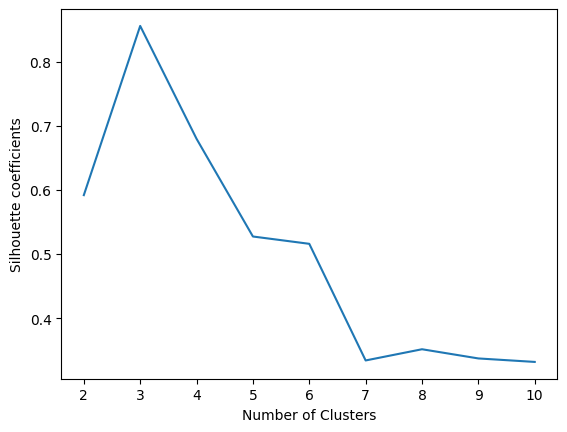

In [29]:
##plotting the silhouette coefficients
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette coefficients")
plt.show()